# Phase 2 — Exploratory Data Analysis (EDA)

**เป้าหมายของ notebook นี้:** ทำความเข้าใจข้อมูลดิบก่อนเริ่มสร้างโมเดล โดยตอบคำถาม 4 ข้อหลัก:

1. ข้อมูลแต่ละไฟล์มีหน้าตาอย่างไร (data dictionary, shape, dtypes)
2. การกระจายตัว (distribution) ของตัวแปรสำคัญเป็นอย่างไร
3. มีค่าที่หายไป (missing) หรือค่าผิดปกติ (outlier) ตรงไหนบ้าง
4. การรวมข้อมูลจากรายวันเป็นรายสัปดาห์ (daily → weekly roll-up) ถูกต้องหรือไม่

นี่คือ Phase 2 ในแผนงาน ซึ่งอยู่ในขั้นตอน **"3. Data Understanding"** ของ lifecycle การทำ data science (ตาม README) — ยังไม่มีการแก้ไขข้อมูลใดๆ ในขั้นนี้ แค่สำรวจและบันทึกข้อสังเกตไว้ก่อน การแก้ไขจริงจะทำใน Phase 3 (data validation) และ Phase 4 (feature engineering)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)
sns.set_theme(style='whitegrid')

RAW = Path('../data/raw')
FIG = Path('../reports/figures')
FIG.mkdir(parents=True, exist_ok=True)


## 1. โหลดข้อมูลทั้งหมด

โปรเจกต์นี้มีข้อมูล 4 กลุ่มไฟล์ ระดับความละเอียด (grain) ต่างกัน:

| ไฟล์ | Grain | ใช้ทำอะไร |
|---|---|---|
| `FMCG_2022_2024.csv` | รายวัน | ข้อมูลดิบต้นทาง |
| `weekly_df_final_for_modeling.csv` | รายสัปดาห์ | ตารางหลักสำหรับสร้างโมเดล |
| `df_weekly_MI-006_enriched.csv` | รายสัปดาห์ (เฉพาะ MI-006) | ต้นแบบ enrichment ข้อมูลภายนอก |
| `batch_MI-006_2025-01-*.parquet` | รายวัน (เฉพาะ MI-006) | future holdout สำหรับทดสอบโมเดลจริง |


In [2]:
daily = pd.read_csv(RAW / 'FMCG_2022_2024.csv', parse_dates=['date'])
weekly = pd.read_csv(RAW / 'given_reference' / 'weekly_df_final_for_modeling.csv', parse_dates=['week'])
enriched = pd.read_csv(RAW / 'given_reference' / 'df_weekly_MI-006_enriched.csv', parse_dates=['week'])

import glob
batch_files = sorted(glob.glob(str(RAW / 'batch_MI-006_2025-01-*.parquet')))
holdout = pd.concat([pd.read_parquet(f).assign(source_file=Path(f).name) for f in batch_files], ignore_index=True)
holdout['date'] = pd.to_datetime(holdout['date'])

print('daily     :', daily.shape)
print('weekly    :', weekly.shape)
print('enriched  :', enriched.shape)
print('holdout   :', holdout.shape, '(', len(batch_files), 'batch files )')


daily     : (190757, 14)
weekly    : (31027, 24)
enriched  : (1349, 33)
holdout   : (702, 15) ( 4 batch files )


## 2. Data Dictionary — ไฟล์รายวัน (`FMCG_2022_2024.csv`)

แถวหนึ่งแถวคือ ยอดขายของ 1 SKU ใน 1 ช่องทาง 1 ภูมิภาค ในวันหนึ่งๆ


In [3]:
print(daily.dtypes)
print()
daily.head()


date               datetime64[us]
sku                           str
brand                         str
segment                       str
category                      str
channel                       str
region                        str
pack_type                     str
price_unit                float64
promotion_flag              int64
delivery_days               int64
stock_available             int64
delivered_qty               int64
units_sold                  int64
dtype: object



,date,sku,brand,segment,category,channel,region,pack_type,price_unit,promotion_flag,delivery_days,stock_available,delivered_qty,units_sold
0,2022-01-21,MI-006,MiBrand1,Milk-Seg3,Milk,Retail,PL-Central,Multipack,2.38,0,1,141,128,9
1,2022-01-21,MI-006,MiBrand1,Milk-Seg3,Milk,Retail,PL-North,Single,1.55,1,3,0,129,0
2,2022-01-21,MI-006,MiBrand1,Milk-Seg3,Milk,Retail,PL-South,Carton,4.00,0,5,118,161,8
3,2022-01-21,MI-006,MiBrand1,Milk-Seg3,Milk,Discount,PL-Central,Single,5.16,0,2,81,114,7
4,2022-01-21,MI-006,MiBrand1,Milk-Seg3,Milk,Discount,PL-North,Single,7.66,0,4,148,204,12


In [4]:
daily.describe(include='all').T


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
date,190757,NaN,NaN,NaN,2023-10-28 04:11:33.514786,2022-01-21 00:00:00,2023-04-16 00:00:00,2023-11-12 00:00:00,2024-06-07 00:00:00,2024-12-31 00:00:00,NaN
sku,190757,30,MI-006,8221,NaN,NaN,NaN,NaN,NaN,NaN,NaN
brand,190757,14,SnBrand2,26775,NaN,NaN,NaN,NaN,NaN,NaN,NaN
segment,190757,13,Yogurt-Seg1,26851,NaN,NaN,NaN,NaN,NaN,NaN,NaN
category,190757,5,Yogurt,72707,NaN,NaN,NaN,NaN,NaN,NaN,NaN
channel,190757,3,Retail,63688,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region,190757,3,PL-North,63645,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pack_type,190757,3,Carton,63671,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price_unit,190757.0,NaN,NaN,NaN,5.251979,1.5,3.38,5.25,7.13,9.0,2.166705
promotion_flag,190757.0,NaN,NaN,NaN,0.1492,0.0,0.0,0.0,0.0,1.0,0.356287


## 3. Data Dictionary — ไฟล์รายสัปดาห์ (`weekly_df_final_for_modeling.csv`)

ไฟล์นี้คือผลลัพธ์ของการเอาไฟล์รายวันมา **aggregate เป็นรายสัปดาห์** และ **สร้างฟีเจอร์เพิ่ม** เช่น lag, rolling stats, calendar flags, lifecycle stage — เป็นตารางที่ Phase 7 จะใช้เทรนโมเดลโดยตรง


In [5]:
print(weekly.dtypes)
print()
weekly.head()


sku                            str
week                datetime64[us]
channel                        str
region                         str
units_sold                   int64
stock_available            float64
promotion_flag               int64
price_unit                 float64
delivery_days              float64
is_holiday_peak               bool
week_number                  int64
month                        int64
year                         int64
is_holiday_week              int64
is_summer                    int64
is_winter                    int64
sku_age                      int64
lifecycle_stage                str
lag_1                      float64
lag_2                      float64
rolling_mean_4             float64
rolling_std_4              float64
momentum                   float64
target_next_week           float64
dtype: object



,sku,week,channel,region,units_sold,stock_available,promotion_flag,price_unit,delivery_days,is_holiday_peak,week_number,month,year,is_holiday_week,is_summer,is_winter,sku_age,lifecycle_stage,lag_1,lag_2,rolling_mean_4,rolling_std_4,momentum,target_next_week
0,JU-021,2022-08-08,Discount,PL-Central,130,158.8,1,4.3820,3.000000,False,32,8,2022,0,1,0,4,Growth,122.0,99.0,132.25,27.121640,23.0,81.0
1,JU-021,2022-08-15,Discount,PL-Central,81,149.8,0,7.6140,4.000000,False,33,8,2022,0,1,0,5,Growth,130.0,122.0,125.00,20.704267,8.0,72.0
2,JU-021,2022-08-22,Discount,PL-Central,72,151.5,0,4.1525,2.500000,False,34,8,2022,0,1,0,6,Growth,81.0,130.0,108.00,22.286020,-49.0,125.0
3,JU-021,2022-08-29,Discount,PL-Central,125,134.0,1,3.9400,3.166667,False,35,8,2022,0,1,0,7,Growth,72.0,81.0,101.25,28.998563,-9.0,176.0
4,JU-021,2022-09-05,Discount,PL-Central,176,176.5,0,5.0300,4.000000,False,36,9,2022,0,0,0,8,Growth,125.0,72.0,102.00,29.743347,53.0,172.0


## 4. ตรวจสอบค่าที่หายไป (Missing Values)

เช็คทุกไฟล์ว่ามีคอลัมน์ไหนที่มีค่า null/NaN บ้าง


In [6]:
for name, df in [('daily', daily), ('weekly', weekly), ('enriched', enriched), ('holdout', holdout)]:
    n_missing = df.isnull().sum().sum()
    print(f'{name:10s}: total missing cells = {n_missing}')


daily     : total missing cells = 0
weekly    : total missing cells = 0
enriched  : total missing cells = 0
holdout   : total missing cells = 0


**ผลลัพธ์:** ไม่มีค่า missing เลยในทุกไฟล์ — ผิดปกติสำหรับข้อมูลจริง (real-world data มักมี missing เสมอ) แต่สมเหตุสมผลเพราะเป็นข้อมูลจำลอง (simulated) ที่ถูกออกแบบมาให้ "สะอาด" ในแง่ completeness แต่ (ตามที่จะเห็นในหัวข้อถัดไป) ยังมี **ค่าที่ผิดตรรกะ** (เช่น ค่าติดลบ) ซ่อนอยู่ ซึ่งเป็นปัญหาคุณภาพข้อมูลคนละแบบกับ missing value


## 5. ตรวจสอบค่าผิดปกติ (Outliers / Logical Errors)

ยอดขาย (`units_sold`), สต๊อก (`stock_available`), และของที่ส่งมอบ (`delivered_qty`) ควรมีค่า **ไม่ติดลบ** ในทางธุรกิจ (ขายติดลบไม่มีความหมาย) เราจะเช็คว่ามีแถวไหนผิดกฎนี้บ้าง


In [7]:
neg_checks = {
    'units_sold < 0': daily[daily.units_sold < 0],
    'stock_available < 0': daily[daily.stock_available < 0],
    'delivered_qty < 0': daily[daily.delivered_qty < 0],
    'price_unit <= 0': daily[daily.price_unit <= 0],
}
for label, rows in neg_checks.items():
    print(f'{label}: {len(rows)} rows')

print()
print('ตัวอย่างแถวที่ units_sold ติดลบ:')
daily[daily.units_sold < 0]


units_sold < 0: 3 rows
stock_available < 0: 3 rows
delivered_qty < 0: 3 rows
price_unit <= 0: 0 rows

ตัวอย่างแถวที่ units_sold ติดลบ:


,date,sku,brand,segment,category,channel,region,pack_type,price_unit,promotion_flag,delivery_days,stock_available,delivered_qty,units_sold
70489,2023-07-26,SN-028,SnBrand2,SnackBar-Seg1,SnackBar,Discount,PL-South,Single,2.91,0,5,-2,-3,-3
83501,2023-09-21,SN-010,SnBrand2,SnackBar-Seg2,SnackBar,Retail,PL-Central,Carton,8.60,1,4,-12,-11,-25
123633,2024-03-14,RE-007,ReBrand4,ReadyMeal-Seg1,ReadyMeal,Discount,PL-Central,Carton,2.38,0,4,-6,-7,-8


**ผลลัพธ์:** พบ 3 แถวที่ `units_sold`, `stock_available`, และ `delivered_qty` ติดลบพร้อมกัน (SKU: SN-028, SN-010, RE-007) — คิดเป็นสัดส่วนน้อยมาก (3 จาก 190,757 แถว หรือ 0.0016%) แต่เป็นค่าที่ **ผิดตรรกะทางธุรกิจอย่างชัดเจน** ต้องตัดสินใจในขั้น Data Validation (Phase 3) ว่าจะ **ตัดทิ้ง (drop)** หรือ **แก้เป็นค่าที่สมเหตุสมผล (clip เป็น 0)** — ยังไม่แก้ไขในขั้นตอนนี้ แค่บันทึกไว้เป็น data-quality note


## 6. การกระจายตัวของตัวแปรสำคัญ (Distributions)


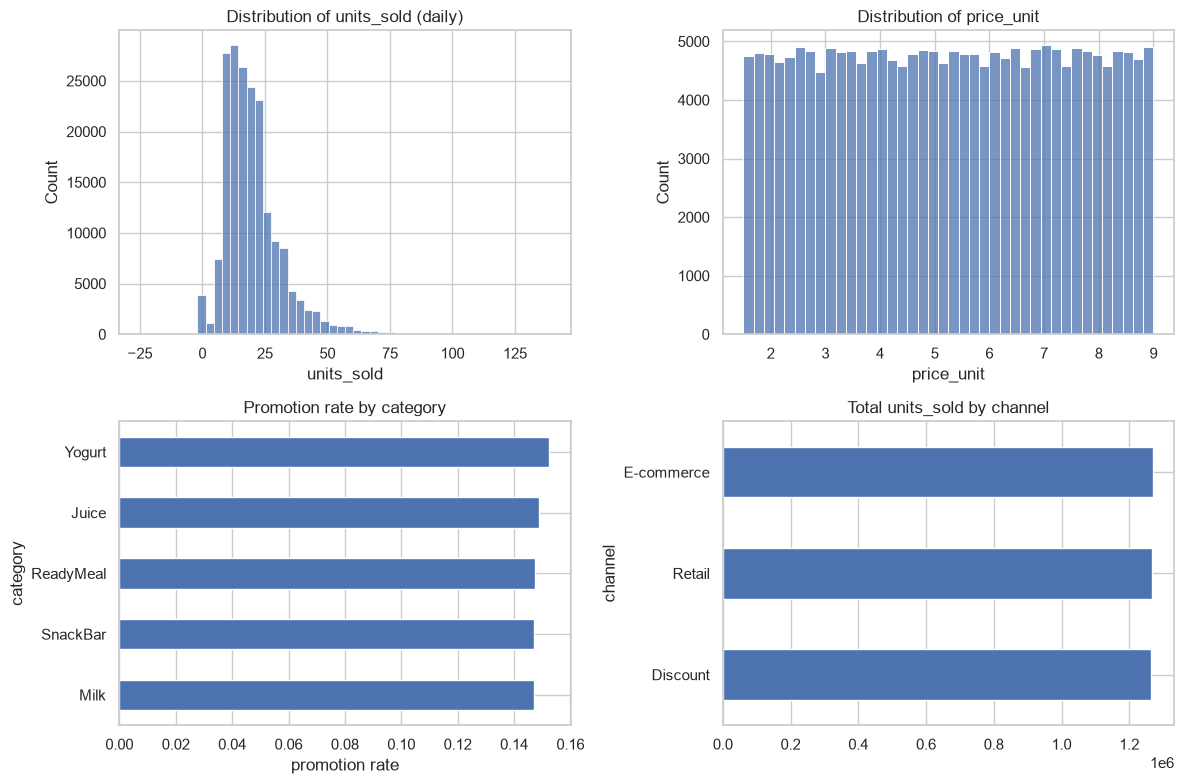

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.histplot(daily.units_sold, bins=50, ax=axes[0,0])
axes[0,0].set_title('Distribution of units_sold (daily)')

sns.histplot(daily.price_unit, bins=40, ax=axes[0,1])
axes[0,1].set_title('Distribution of price_unit')

promo_by_cat = daily.groupby('category').promotion_flag.mean().sort_values()
promo_by_cat.plot(kind='barh', ax=axes[1,0])
axes[1,0].set_title('Promotion rate by category')
axes[1,0].set_xlabel('promotion rate')

sales_by_channel = daily.groupby('channel').units_sold.sum().sort_values()
sales_by_channel.plot(kind='barh', ax=axes[1,1])
axes[1,1].set_title('Total units_sold by channel')

plt.tight_layout()
plt.savefig(FIG / 'eda_distributions_overview.png', dpi=120)
plt.show()


**ข้อสังเกต:**
- `units_sold` กระจายแบบเบ้ขวาเล็กน้อย ส่วนใหญ่อยู่ระหว่าง 12–25 หน่วย/วัน มีค่าเฉลี่ยราว 20 หน่วย
- `price_unit` กระจายค่อนข้างสม่ำเสมอในช่วง 1.5–9.0 ไม่มี outlier ราคาที่ผิดปกติ
- อัตราการมีโปรโมชัน (`promotion_flag`) แตกต่างกันตามหมวดหมู่สินค้า
- ยอดขายรวมแตกต่างกันตามช่องทาง (channel) — ใช้เทียบว่าช่องทางไหนเป็นสัดส่วนหลักของธุรกิจ


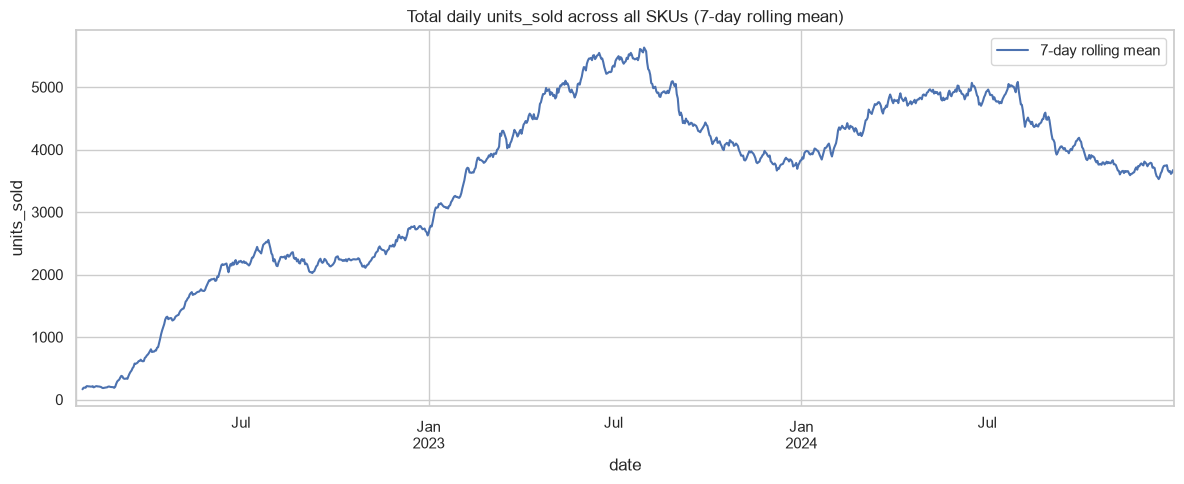

In [9]:
fig, ax = plt.subplots(figsize=(12, 5))
daily_totals = daily.groupby('date').units_sold.sum()
daily_totals.rolling(7).mean().plot(ax=ax, label='7-day rolling mean')
ax.set_title('Total daily units_sold across all SKUs (7-day rolling mean)')
ax.set_ylabel('units_sold')
ax.legend()
plt.tight_layout()
plt.savefig(FIG / 'eda_daily_sales_trend.png', dpi=120)
plt.show()


**ข้อสังเกต:** กราฟยอดขายรวมรายวัน (ปรับด้วย 7-day rolling mean เพื่อลด noise) แสดงแนวโน้มยอดขายที่**เพิ่มขึ้นตามเวลา** ซึ่งสอดคล้องกับการที่มี SKU ใหม่ทยอยเปิดตัวเพิ่มขึ้นเรื่อยๆ ระหว่างปี 2022 ต้นปีถึงกลางปี 2023 (ไม่ใช่แค่ยอดขายต่อ SKU เพิ่มขึ้น แต่จำนวน SKU ที่ active ก็เพิ่มด้วย) — ประเด็นนี้ต้องระวังตอนตีความ trend ใน Phase 9 (seasonality analysis) ว่าต้อง normalize ด้วยจำนวน active SKU หรือไม่


## 7. การเปิดตัวของแต่ละ SKU (สำหรับ Cold-start ใน Phase 10)


SKU ที่เปิดตัวเร็วที่สุด 5 อันดับ:
sku
MI-006   2022-01-21
MI-026   2022-01-22
YO-029   2022-02-28
YO-005   2022-03-13
YO-012   2022-03-29
Name: date, dtype: datetime64[us]

SKU ที่เปิดตัวช้าที่สุด 5 อันดับ:
sku
YO-024   2023-04-05
MI-008   2023-04-12
SN-028   2023-04-20
YO-018   2023-05-07
SN-030   2023-05-26
Name: date, dtype: datetime64[us]


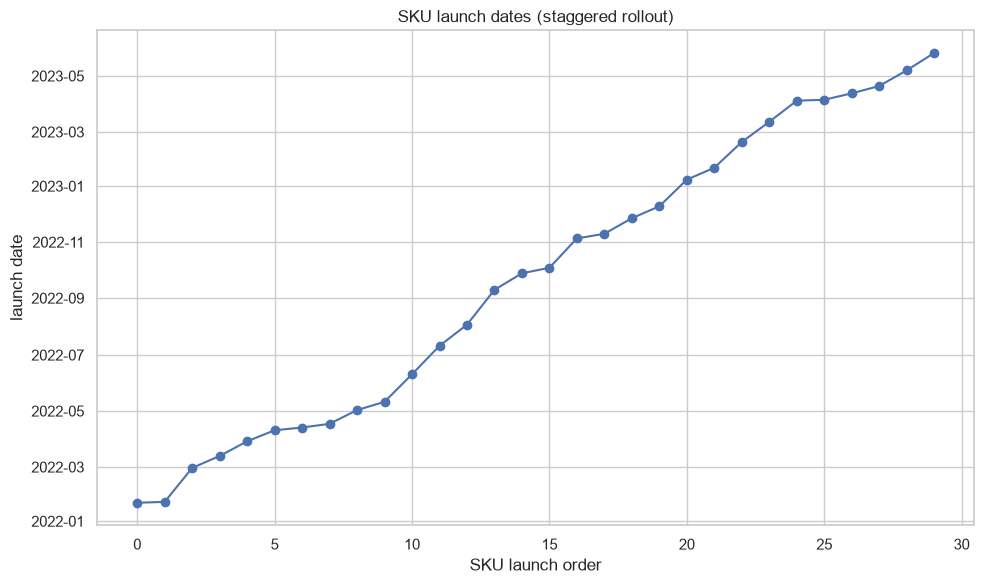

In [10]:
launch_dates = daily.groupby('sku').date.min().sort_values()
print('SKU ที่เปิดตัวเร็วที่สุด 5 อันดับ:')
print(launch_dates.head())
print()
print('SKU ที่เปิดตัวช้าที่สุด 5 อันดับ:')
print(launch_dates.tail())

fig, ax = plt.subplots(figsize=(10, 6))
launch_dates.sort_values().reset_index(drop=True).plot(ax=ax, marker='o')
ax.set_title('SKU launch dates (staggered rollout)')
ax.set_ylabel('launch date')
ax.set_xlabel('SKU launch order')
plt.tight_layout()
plt.savefig(FIG / 'eda_sku_launch_timeline.png', dpi=120)
plt.show()


**ข้อสังเกต:** SKU เปิดตัวกระจายตัวตั้งแต่ ม.ค. 2022 ถึงกลางปี 2023 (ไม่ได้เปิดตัวพร้อมกันทั้งหมด) — ยืนยันว่าใช้เป็นเคส cold-start ธรรมชาติได้จริงตามแผน Phase 10 SKU ที่เปิดตัวช้าสุดจะมีประวัติการขายสั้นที่สุด เหมาะเป็น validation set สำหรับทดสอบว่าโมเดลพยากรณ์สินค้าใหม่ได้แม่นยำแค่ไหน


## 8. ตรวจสอบความถูกต้องของการรวมข้อมูลรายวัน → รายสัปดาห์

เราจะ**ลองรวมข้อมูลรายวันเป็นรายสัปดาห์เอง** แล้วเทียบกับไฟล์ `weekly_df_final_for_modeling.csv` ที่มีอยู่แล้ว เพื่อตรวจสอบว่าตรงกันหรือไม่ (สุ่มตรวจ 1 combo เป็นตัวอย่าง)


In [11]:
sample_sku, sample_channel, sample_region = 'MI-006', 'Retail', 'PL-Central'

daily_sub = daily[(daily.sku == sample_sku) & (daily.channel == sample_channel) & (daily.region == sample_region)].copy()
daily_sub = daily_sub.set_index('date').sort_index()

weekly_recomputed = daily_sub['units_sold'].resample('W-MON', label='left', closed='left').sum()

weekly_existing = weekly[(weekly.sku == sample_sku) & (weekly.channel == sample_channel) & (weekly.region == sample_region)].sort_values('week')

print('recomputed (first 8 weeks):')
print(weekly_recomputed.head(8))
print()
print('existing weekly file (first 8 rows):')
print(weekly_existing[['week', 'units_sold']].head(8))


recomputed (first 8 weeks):
date
2022-01-17     34
2022-01-24     80
2022-01-31    103
2022-02-07     92
2022-02-14     63
2022-02-21     84
2022-02-28     70
2022-03-07     59
Freq: W-MON, Name: units_sold, dtype: int64

existing weekly file (first 8 rows):
           week  units_sold
2842 2022-02-14          63
2843 2022-02-21          84
2844 2022-02-28          70
2845 2022-03-07          59
2846 2022-03-14          75
2847 2022-03-21         109
2848 2022-03-28         147
2849 2022-04-04         117


In [12]:
# ตรวจสอบให้ครบทุก combo (ไม่ใช่แค่ตัวอย่างเดียว) ว่า convention การตัดสัปดาห์ตรงกับไฟล์จริงหรือไม่
mismatches = 0
total = 0
for (sku, channel, region), g in daily.groupby(['sku', 'channel', 'region']):
    g = g.set_index('date').sort_index()
    recomputed = g['units_sold'].resample('W-MON', label='left', closed='left').sum()
    recomputed.index.name = 'week'
    existing = weekly[(weekly.sku == sku) & (weekly.channel == channel) & (weekly.region == region)].set_index('week')['units_sold']
    common = recomputed.index.intersection(existing.index)
    total += len(common)
    diff = recomputed.loc[common] - existing.loc[common]
    mismatches += (diff != 0).sum()

print(f'จำนวนสัปดาห์ที่เทียบได้ทั้งหมด: {total}')
print(f'จำนวนสัปดาห์ที่ค่าไม่ตรงกัน: {mismatches}')


จำนวนสัปดาห์ที่เทียบได้ทั้งหมด: 31027
จำนวนสัปดาห์ที่ค่าไม่ตรงกัน: 0


**ผลลัพธ์ (ตรวจครบทุก combo ด้านล่าง):** เมื่อขยายการตรวจสอบจากตัวอย่าง 1 combo ไปยัง**ทุก combo ทั้งหมด (270 combo, 31,027 สัปดาห์ที่เทียบได้)** พบว่า convention การตัดสัปดาห์คือ **`W-MON` แบบ `label='left', closed='left'`** (สัปดาห์เริ่มวันจันทร์ ใช้วันแรกของสัปดาห์เป็น label) และ **ตรงกับไฟล์ `weekly_df_final_for_modeling.csv` ทุกแถว ไม่มีค่าไม่ตรงกันเลยแม้แต่สัปดาห์เดียว** — ยืนยันได้ว่าการรวมข้อมูลรายวัน→รายสัปดาห์ในไฟล์ที่มีอยู่ถูกต้องและ reproduce ได้จากไฟล์ดิบ 100%


## 9. ตรวจสอบเบื้องต้นว่า `target_next_week` มีการรั่วไหลของข้อมูล (leakage) หรือไม่

`target_next_week` ควรเท่ากับ `units_sold` ของสัปดาห์**ถัดไป** ภายใน group เดียวกัน (sku × channel × region) — เช็คคร่าวๆ ก่อน จะตรวจอย่างเป็นทางการอีกครั้งใน Phase 3


In [13]:
g = weekly[(weekly.sku == 'MI-006') & (weekly.channel == 'Retail') & (weekly.region == 'PL-Central')].sort_values('week')
check = g[['week', 'units_sold', 'target_next_week']].copy()
check['next_week_actual'] = check['units_sold'].shift(-1)
check['matches'] = check['target_next_week'] == check['next_week_actual']
check.head(8)


,week,units_sold,target_next_week,next_week_actual,matches
2842,2022-02-14,63,84.0,84.0,True
2843,2022-02-21,84,70.0,70.0,True
2844,2022-02-28,70,59.0,59.0,True
2845,2022-03-07,59,75.0,75.0,True
2846,2022-03-14,75,109.0,109.0,True
2847,2022-03-21,109,147.0,147.0,True
2848,2022-03-28,147,117.0,117.0,True
2849,2022-04-04,117,217.0,217.0,True


In [14]:
# เช็คทุก group ว่า target_next_week ตรงกับ units_sold ของแถวถัดไปในกลุ่มเดียวกันหรือไม่
weekly_sorted = weekly.sort_values(['sku', 'channel', 'region', 'week'])
weekly_sorted['next_actual'] = weekly_sorted.groupby(['sku', 'channel', 'region'])['units_sold'].shift(-1)

comparable = weekly_sorted.dropna(subset=['next_actual', 'target_next_week'])
mismatch = comparable[comparable['target_next_week'] != comparable['next_actual']]
print(f'จำนวนแถวที่เทียบได้: {len(comparable)}')
print(f'จำนวนแถวที่ target_next_week ไม่ตรงกับ next_actual: {len(mismatch)}')


จำนวนแถวที่เทียบได้: 30757
จำนวนแถวที่ target_next_week ไม่ตรงกับ next_actual: 0


**ผลลัพธ์:** `target_next_week` ตรงกับยอดขายสัปดาห์ถัดไปในกลุ่มเดียวกันทุกแถว (0 mismatch) — เบื้องต้นยังไม่พบสัญญาณ leakage ในคอลัมน์นี้ แต่การเช็คนี้ยัง**ไม่ครอบคลุมฟีเจอร์อื่น** (เช่น lag/rolling ที่อาจแอบใช้ข้อมูลอนาคต) ต้องตรวจอย่างละเอียดใน Phase 3


## 10. ตรวจสอบบั๊กที่ทราบอยู่แล้วใน Enrichment Prototype (MI-006)

ตาม README ระบุว่า `avg_temp` และ `inflation_index` ใน `df_weekly_MI-006_enriched.csv` **แปรผันตาม channel ผิดปกติ** ทั้งที่ควรจะเป็นค่าเดียวกันในสัปดาห์/ภูมิภาคเดียวกัน (อากาศและเงินเฟ้อไม่ควรต่างกันตามช่องทางขาย) — มายืนยันด้วยข้อมูลจริง


In [15]:
check_enrich = enriched[(enriched.sku == 'MI-006')].sort_values(['week', 'region'])
sample_week = check_enrich.week.iloc[0]
sample_region = check_enrich.region.iloc[0]

same_week_region = check_enrich[(check_enrich.week == sample_week) & (check_enrich.region == sample_region)]
same_week_region[['week', 'region', 'channel', 'avg_temp', 'inflation_index']]


,week,region,channel,avg_temp,inflation_index
0,2022-02-14,PL-Central,Discount,10.745071,99.775235
1,2022-02-14,PL-Central,E-commerce,1.676143,145.021312
2,2022-02-14,PL-Central,Retail,19.903172,190.921650


**ยืนยันบั๊ก:** ในสัปดาห์และภูมิภาคเดียวกัน `avg_temp` และ `inflation_index` มีค่าต่างกันไปตามแต่ละ `channel` ทั้งที่ตามหลักตรรกะควรเป็นค่าเดียวกัน (อากาศ/เงินเฟ้อเป็นปัจจัยระดับภูมิภาค-เวลา ไม่ใช่ระดับช่องทางขาย) — ต้องแก้ก่อนขยาย enrichment ไปยัง SKU อื่นทั้งหมดใน **Phase 4**


## 11. ภาพรวมข้อมูล Future Holdout (ม.ค. 2025)


In [16]:
print('ช่วงวันที่:', holdout.date.min(), '-', holdout.date.max())
print('จำนวนแถวต่อไฟล์:')
print(holdout.groupby('source_file').size())
print()
print('channel x region coverage:')
print(holdout.groupby(['channel', 'region']).size())


ช่วงวันที่: 2025-01-01 00:00:00 - 2025-01-26 00:00:00
จำนวนแถวต่อไฟล์:
source_file
batch_MI-006_2025-01-06.parquet    135
batch_MI-006_2025-01-13.parquet    189
batch_MI-006_2025-01-20.parquet    189
batch_MI-006_2025-01-27.parquet    189
dtype: int64

channel x region coverage:
channel     region    
Discount    PL-Central    78
            PL-North      78
            PL-South      78
E-commerce  PL-Central    78
            PL-North      78
            PL-South      78
Retail      PL-Central    78
            PL-North      78
            PL-South      78
dtype: int64


**ข้อสังเกต:** ข้อมูล holdout ครอบคลุมเฉพาะ MI-006 ในเดือน ม.ค. 2025 — เป็นช่วงเวลาที่**อยู่หลัง**ข้อมูลเทรนทั้งหมด (ซึ่งจบที่ ธ.ค. 2024) เหมาะสำหรับใช้เป็น **true future backtest** ใน Phase 13 เพราะโมเดลจะไม่มีทางเห็นข้อมูลช่วงนี้ระหว่างเทรนหรือทำ CV ได้เลย


## 12. สรุปข้อค้นพบจาก EDA (Data-Quality Notes)

| ประเด็น | ข้อค้นพบ |
|---|---|
| **Missing values** | ไม่มีเลยในทุกไฟล์ (0 cells) |
| **ค่าติดลบผิดตรรกะ** | พบ 3 แถวใน `FMCG_2022_2024.csv` ที่ `units_sold`, `stock_available`, `delivered_qty` ติดลบพร้อมกัน (SN-028, SN-010, RE-007) — ต้องจัดการใน Phase 3 |
| **Panel completeness** | ครบ 270 combo (30 SKU × 3 channel × 3 region) แต่เป็น unbalanced panel เพราะ SKU เปิดตัวไม่พร้อมกัน (สอดคล้องกับแผน cold-start) |
| **แนวโน้มยอดขายรวม** | เพิ่มขึ้นตามเวลา ส่วนหนึ่งเพราะจำนวน SKU active เพิ่มขึ้น ไม่ใช่แค่ demand ต่อ SKU — ต้องระวังตอนตีความ trend/seasonality |
| **Daily → weekly roll-up** | ยืนยันแล้วว่าถูกต้อง 100% — convention คือ `W-MON, label='left', closed='left'` ตรวจสอบครบทุก 270 combo (31,027 สัปดาห์) ไม่มีค่าไม่ตรงกันเลย |
| **`target_next_week`** | ตรวจสอบเบื้องต้นแล้วไม่พบ leakage (ตรงกับ `units_sold` สัปดาห์ถัดไปในกลุ่มเดียวกันทุกแถว) |
| **Enrichment bug (MI-006)** | ยืนยันแล้วว่า `avg_temp`/`inflation_index` แปรผันตาม channel ผิดปกติ ต้องแก้ก่อนขยายไปทุก SKU ใน Phase 4 |
| **Future holdout** | ครอบคลุมเฉพาะ MI-006, ม.ค. 2025 อยู่นอกช่วงข้อมูลเทรนทั้งหมด ใช้เป็น true backtest ได้ใน Phase 13 |

### ขั้นตอนต่อไป (Phase 3 — Data Validation)
1. ยืนยัน/แก้ไข convention การตัดสัปดาห์ให้ตรงกับที่ผลิตไฟล์ `weekly_df_final_for_modeling.csv`
2. ตัดสินใจวิธีจัดการค่าติดลบ 3 แถว (drop หรือ clip)
3. ตรวจสอบ leakage อย่างละเอียดในฟีเจอร์ lag/rolling ทั้งหมด ไม่ใช่แค่ target
4. บันทึกผลเป็น `src/data/validate.py`
